In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir(r'D:\predictive-maintenance-sme')
os.makedirs('assets', exist_ok=True)

train = pd.read_csv('data/processed/train_features.csv')

print("Train shape:", train.shape)
print("Columns sample:")
print(train.columns.tolist()[:15])

Train shape: (7000, 82)
Columns sample:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_encoded', 'Air temperature [K]_rmean_5', 'Air temperature [K]_rstd_5', 'Air temperature [K]_rmax_5']


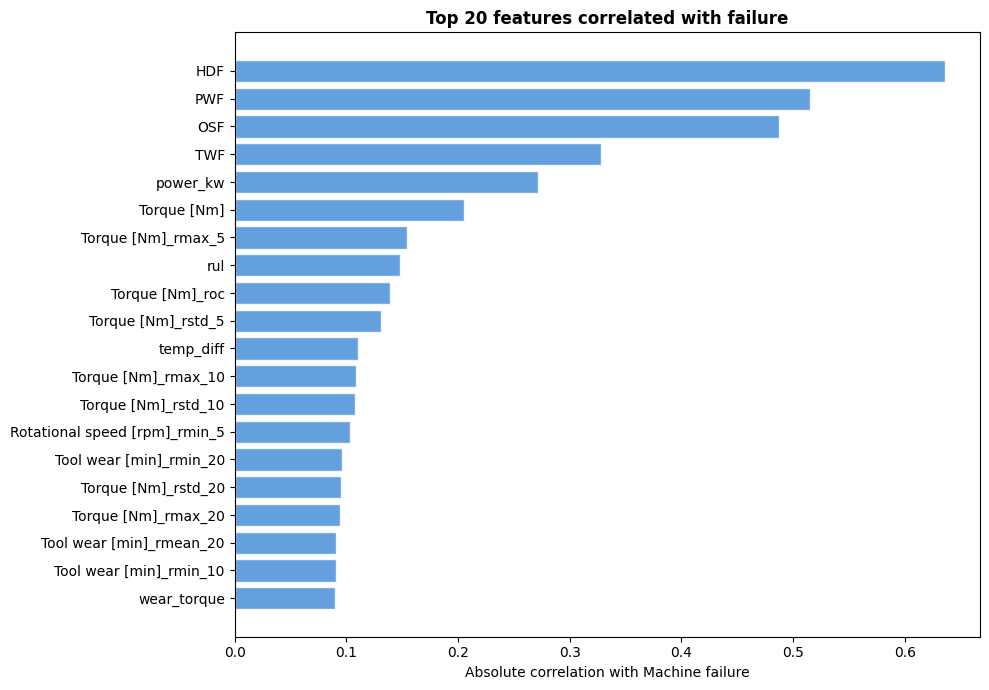

Saved: assets/top_features_correlation.png


In [2]:
TARGET = 'Machine failure'

corr = (
    train.select_dtypes(include=[float, int])
    .corr()[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 7))
bars = plt.barh(
    corr.index[::-1],
    corr.values[::-1],
    color='#4a90d9',
    alpha=0.85,
    edgecolor='white'
)
plt.xlabel('Absolute correlation with Machine failure')
plt.title('Top 20 features correlated with failure', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/top_features_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/top_features_correlation.png")

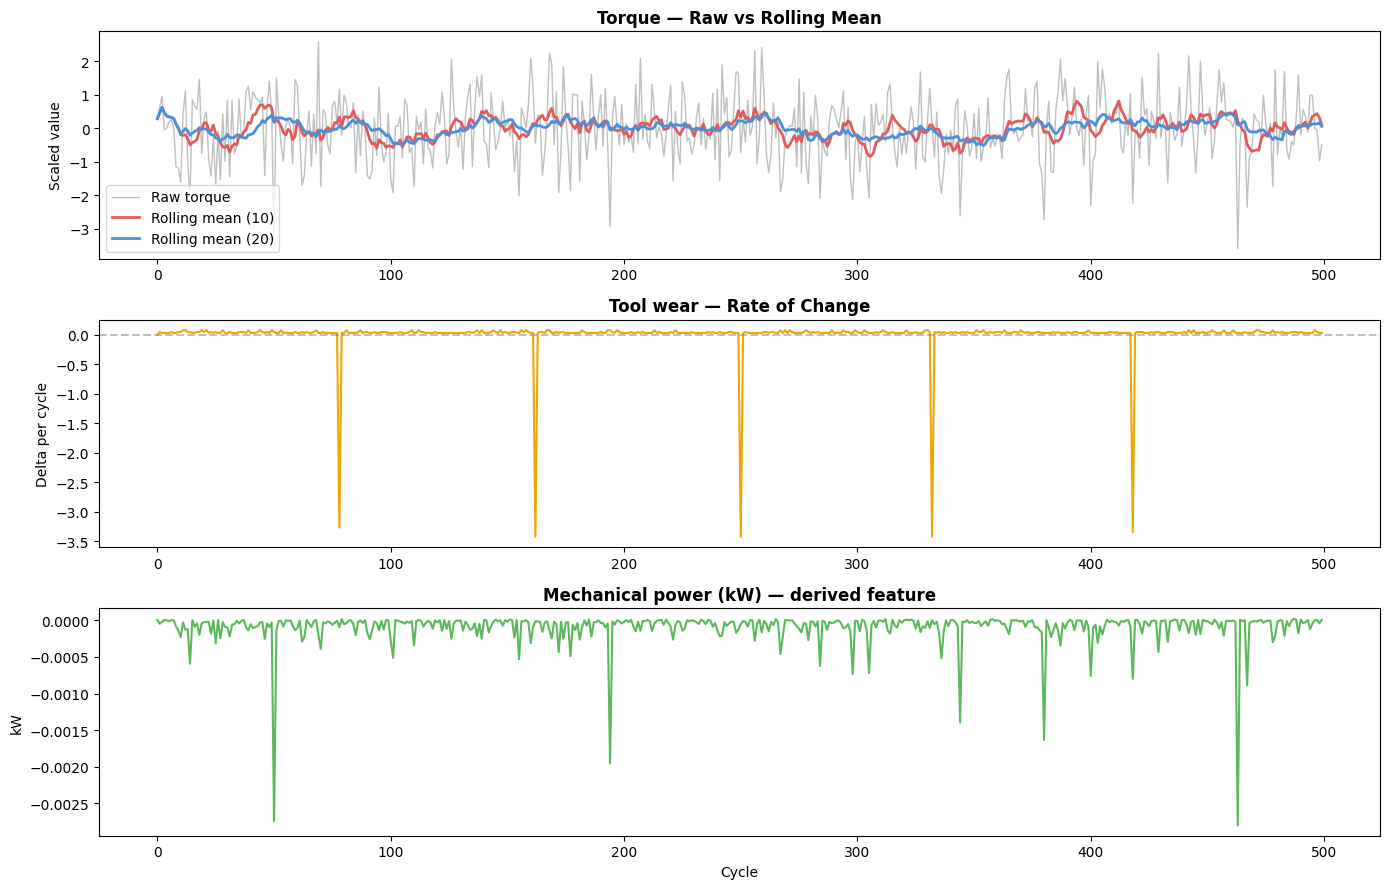

Saved: assets/rolling_features_visualization.png


In [3]:
sample = train.iloc[:500].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

# Raw vs rolling mean
axes[0].plot(sample['Torque [Nm]'],
             alpha=0.5, color='gray', label='Raw torque', linewidth=1)
axes[0].plot(sample['Torque [Nm]_rmean_10'],
             color='#e05c5c', label='Rolling mean (10)', linewidth=2)
axes[0].plot(sample['Torque [Nm]_rmean_20'],
             color='#4a90d9', label='Rolling mean (20)', linewidth=2)
axes[0].set_title('Torque — Raw vs Rolling Mean', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Scaled value')

# Rate of change
axes[1].plot(sample['Tool wear [min]_roc'],
             color='#f0a500', linewidth=1.5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Tool wear — Rate of Change', fontweight='bold')
axes[1].set_ylabel('Delta per cycle')

# Physics feature — power
axes[2].plot(sample['power_kw'],
             color='#5cb85c', linewidth=1.5)
axes[2].set_title('Mechanical power (kW) — derived feature', fontweight='bold')
axes[2].set_ylabel('kW')
axes[2].set_xlabel('Cycle')

plt.tight_layout()
plt.savefig('assets/rolling_features_visualization.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/rolling_features_visualization.png")

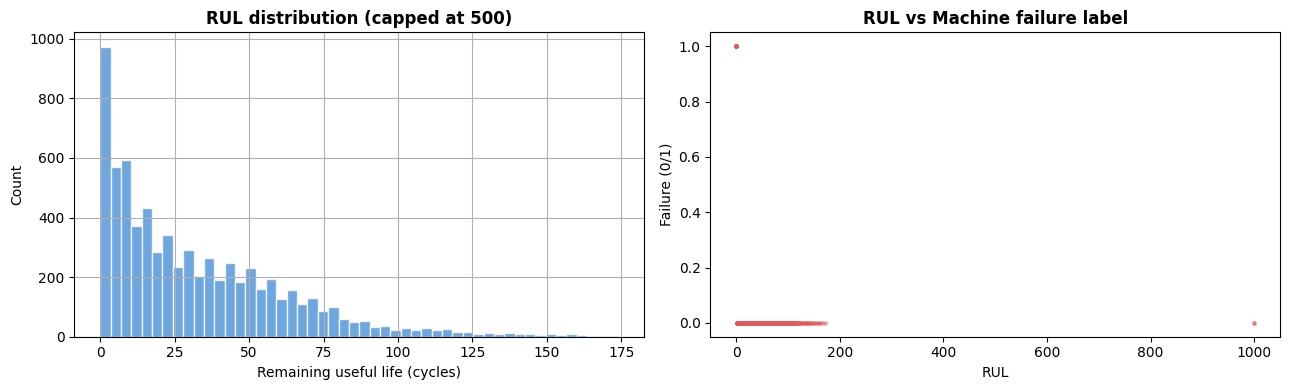

Saved: assets/rul_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# RUL histogram
train[train['rul'] < 500]['rul'].hist(
    bins=50, ax=axes[0],
    color='#4a90d9', alpha=0.8, edgecolor='white'
)
axes[0].set_title('RUL distribution (capped at 500)', fontweight='bold')
axes[0].set_xlabel('Remaining useful life (cycles)')
axes[0].set_ylabel('Count')

# RUL vs failure
axes[1].scatter(
    train['rul'],
    train[TARGET],
    alpha=0.1, s=5,
    color='#e05c5c'
)
axes[1].set_title('RUL vs Machine failure label', fontweight='bold')
axes[1].set_xlabel('RUL')
axes[1].set_ylabel('Failure (0/1)')

plt.tight_layout()
plt.savefig('assets/rul_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/rul_distribution.png")

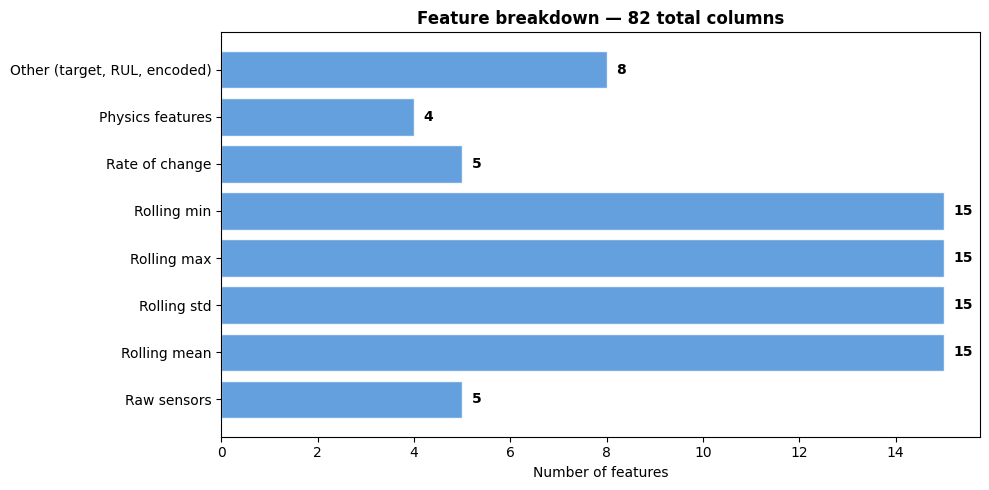

Saved: assets/feature_breakdown.png


In [5]:
feature_groups = {
    'Raw sensors': 5,
    'Rolling mean': 15,
    'Rolling std': 15,
    'Rolling max': 15,
    'Rolling min': 15,
    'Rate of change': 5,
    'Physics features': 4,
    'Other (target, RUL, encoded)': 8
}

plt.figure(figsize=(10, 5))
bars = plt.barh(
    list(feature_groups.keys()),
    list(feature_groups.values()),
    color='#4a90d9', alpha=0.85, edgecolor='white'
)
for bar, val in zip(bars, feature_groups.values()):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')
plt.xlabel('Number of features')
plt.title('Feature breakdown — 82 total columns', fontweight='bold')
plt.tight_layout()
plt.savefig('assets/feature_breakdown.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: assets/feature_breakdown.png")